In [1]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Car_Depreciation.csv")
df.head()

,Car_ID,Brand,Model,Year,Original_Price,Current_Price,Mileage,Fuel_Type,Transmission,Description
0,1,Toyota,Corolla,2018,20000,15000,40000,Petrol,Automatic,Reliable compact car with good fuel economy
1,2,BMW,3 Series,2017,40000,22000,60000,Diesel,Automatic,Luxury sedan with premium interior and perform...
2,3,Ford,Focus,2016,18000,9000,80000,Petrol,Manual,Affordable hatchback with decent handling
3,4,Audi,A4,2019,42000,30000,30000,Diesel,Automatic,Stylish luxury car with advanced technology
4,5,Honda,Civic,2015,22000,11000,90000,Petrol,Manual,Durable and efficient car with strong resale v...


In [4]:
df["Depreciation"] = df["Original_Price"] - df["Current_Price"]
df["Depreciation_Rate"] = df["Depreciation"] / df["Original_Price"]

df.head()

,Car_ID,Brand,Model,Year,Original_Price,Current_Price,Mileage,Fuel_Type,Transmission,Description,Depreciation,Depreciation_Rate
0,1,Toyota,Corolla,2018,20000,15000,40000,Petrol,Automatic,Reliable compact car with good fuel economy,5000,0.250000
1,2,BMW,3 Series,2017,40000,22000,60000,Diesel,Automatic,Luxury sedan with premium interior and perform...,18000,0.450000
2,3,Ford,Focus,2016,18000,9000,80000,Petrol,Manual,Affordable hatchback with decent handling,9000,0.500000
3,4,Audi,A4,2019,42000,30000,30000,Diesel,Automatic,Stylish luxury car with advanced technology,12000,0.285714
4,5,Honda,Civic,2015,22000,11000,90000,Petrol,Manual,Durable and efficient car with strong resale v...,11000,0.500000


In [5]:
le_fuel = LabelEncoder()
le_trans = LabelEncoder()

df["Fuel_Type"] = le_fuel.fit_transform(df["Fuel_Type"])
df["Transmission"] = le_trans.fit_transform(df["Transmission"])

In [6]:
tfidf = TfidfVectorizer(stop_words='english')

text_features = tfidf.fit_transform(df["Description"])

text_df = pd.DataFrame(text_features.toarray(), columns=tfidf.get_feature_names_out())

text_df.head()

,advanced,affordable,car,comfortable,compact,decent,durable,economy,efficient,fuel,...,reliable,resale,ride,sedan,smooth,strong,stylish,technology,value,vehicle
0,0.000000,0.0,0.295760,0.0,0.427206,0.0,0.000000,0.427206,0.000000,0.427206,...,0.427206,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0
1,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.472493,0.0,0.000000,0.000000,0.000000,0.000000,0.0
2,0.000000,0.5,0.000000,0.0,0.000000,0.5,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0
3,0.502608,0.0,0.347962,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.502608,0.502608,0.000000,0.0
4,0.000000,0.0,0.295760,0.0,0.000000,0.0,0.427206,0.000000,0.427206,0.000000,...,0.000000,0.427206,0.0,0.000000,0.0,0.427206,0.000000,0.000000,0.427206,0.0


In [7]:
numeric_features = df[[
    "Year", "Mileage", "Original_Price", 
    "Current_Price", "Depreciation_Rate",
    "Fuel_Type", "Transmission"
]]

final_df = pd.concat([numeric_features.reset_index(drop=True), text_df], axis=1)

In [8]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(final_df)

In [9]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_data)

df[["Brand", "Model", "Cluster"]]

,Brand,Model,Cluster
0,Toyota,Corolla,2
1,BMW,3 Series,1
2,Ford,Focus,0
3,Audi,A4,1
4,Honda,Civic,0
5,Mercedes,C-Class,1


In [11]:
print(scaled_data.shape)

(6, 34)


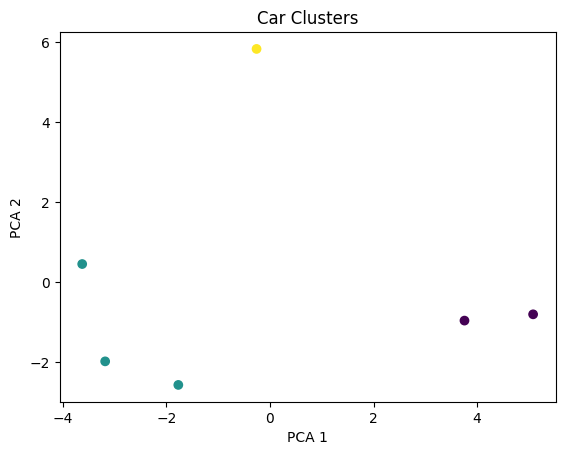

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(scaled_data)

plt.scatter(reduced[:,0], reduced[:,1], c=df["Cluster"])
plt.title("Car Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()